# Titanic 2026 Ensemble Techniques - No Hidden-Label Cheating [Public 0.83014]

### No hidden-label cheating / no answer-key lookup

No hidden Titanic test labels or answer-key file were used to construct the submission in this project.

This statement is intentionally narrower than "fully leakage-free." The final v47 campaign artifact reused predictions from public notebooks and was selected with feedback from the Public leaderboard. Those choices are disclosed below and are why the 0.83014 result is presented as a recorded campaign score rather than an independently certified clean-generalization benchmark.

This notebook is a self-contained Kaggle version of the experiment record. You do not need to open the GitHub repository to understand the main workflow, score progression, modeling ideas, limitations, or how the final submission artifact was produced.

The main focus is the ensemble strategy used across the 2026 campaign: heterogeneous tree ensembles, probability blending, hard voting, seed averaging, modern tabular learners, text-derived signals, relationship-aware rules, and selective prediction guards. The project combined these ideas iteratively rather than relying on one monolithic model.

LLM assistance was used behind the scenes for experiment planning, code drafting, local execution requests, result analysis, and documentation. The LLM was not used as a passenger-level prediction feature. Feature engineering and model training were performed in Python, while the user chose the research direction and approved external submissions.

Headline result: the first recorded Public score was 0.79186 and the selected final artifact, v47, scored 0.83014. There were 17 actual Kaggle submissions; labels v1-v47 are work-stage identifiers, not 47 independent submissions.


## 2026 ensemble toolkit used in this project

This notebook uses "2026 ensemble techniques" as a practical description of the modern combination strategy explored in this campaign, not as a claim that every component was invented in 2026 or that the final pipeline is globally state of the art.

The ensemble stack evolved through several complementary mechanisms:

- Heterogeneous tree averaging: Random Forest, Extra Trees, Gradient Boosting, XGBoost, LightGBM, and CatBoost supplied different inductive biases on the same engineered tabular features.
- Probability blending: the project mixed model probabilities instead of depending on a single estimator, including a 90/10 blend between the original ensemble and TabICLv2 in v4b.
- Hard voting across model families: v5 combined the reference blend with RuleFit and an MLP-PLR component, selecting the majority class rather than averaging every signal into one score.
- Seed averaging: the MLP component averaged predictions from seeds 42, 142, and 242 to reduce dependence on a single random initialization.
- Modern tabular foundation-style models: TabICLv2 and later TabPFN-family candidates were evaluated as complementary learners rather than treated as automatic replacements for classical models.
- Text-derived diversity: character n-gram models over Name, Ticket, and Cabin were used to discover errors that the tabular models did not make in the same way.
- Relationship-aware signals: family/ticket survival information, typed women/child/adult-male group features, empirical-Bayes shrinkage, and WCG-style rules were tested as structured relational signals.
- Selective prediction guards: the strongest late-stage gains came from changing only a small subset of predictions when an auxiliary signal strongly disagreed with the current base. v38, v46, and v47 follow this pattern.
- Validation-aware model selection: repeated folds, group-aware splits, pseudo-test checks, disagreement analysis, and nested-selection experiments were used to challenge candidate improvements, although the final campaign still contains the limitations documented later in this notebook.

The key idea is diversity plus selective combination: use models and feature families that fail differently, then combine or gate them only where the evidence suggests they add complementary signal.


## Reference ensemble architecture: v5

The v5 reference was intentionally heterogeneous. The left branch, v4b, already blended the original multi-tree ensemble with TabICLv2. RuleFit contributed sparse rule-based structure, while the MLP-PLR branch contributed a neural representation whose probabilities were averaged across seeds 42, 142, and 242 before voting.

The final decision was a three-member majority vote. This design illustrates a recurring theme in the project: a component did not need to be the strongest standalone model to be useful if its errors were sufficiently different from the others.



The robust seed-averaged v5 recorded OOF Accuracy 0.85410 and Public 0.79665. The gap later became one reason to distrust small local gains unless they survived additional checks.


In [ ]:
import json
import pandas as pd
from IPython.display import display

history = pd.DataFrame(json.loads(r'''[{"ref": 56824542, "file": "submission.csv", "date": "2026-10-04 13:03:19.343000", "description": "Titanic High-Performance Ensemble Pipeline (WCG+6Models)", "public_score": 0.79186}, {"ref": 56825418, "file": "submission_v2.csv", "date": "2026-10-04 13:40:47.277000", "description": "Titanic v2: Advanced FE + Weighted Blending + WCG Post-Processing", "public_score": 0.78708}, {"ref": 56826952, "file": "submission_v4.csv", "date": "2026-10-04 14:53:18.353000", "description": "Titanic v4: TabICLv2 + Fold-safe WCG", "public_score": 0.78708}, {"ref": 56827009, "file": "submission_v4_blend_90_10.csv", "date": "2026-10-04 14:55:38.210000", "description": "Titanic v4b: 90% v1 + 10% TabICLv2 fold-safe blend", "public_score": 0.79425}, {"ref": 56827698, "file": "submission_v5_robust_vote.csv", "date": "2026-10-04 15:29:26.693000", "description": "v5 robust hard vote: v4b + RuleFit + 3-seed MLP-PLR", "public_score": 0.79665}, {"ref": 56829831, "file": "submission_v9_gunes_all.csv", "date": "2026-10-04 17:15:18.470000", "description": "v9 Gunes Evitan fold-safe feature transfer: gunes_all panel", "public_score": 0.78229}, {"ref": 56830042, "file": "submission_v10_gunes_original_reproduction.csv", "date": "2026-10-04 17:26:43.107000", "description": "v10 exact Gunes Evitan tutorial reproduction: 26 features + 1750-tree RF 5-fold", "public_score": 0.81578}, {"ref": 56831596, "file": "submission_v15_switch_t3_t25_cat.csv", "date": "2026-10-04 18:46:40.047000", "description": "v19 validated typed consensus: v5 robust with unanimous TabPFN v3/v2.5 + CatBoost switch", "public_score": 0.79425}, {"ref": 56831621, "file": "submission_v18_v10_guard_all3_weak.csv", "date": "2026-10-04 18:48:51.207000", "description": "v20 validated v10 conservative typed guard: unanimous t3/t25/cat switch only when relation evidence weak", "public_score": 0.811}, {"ref": 56832161, "file": "submission_v25_final_majority.csv", "date": "2026-10-04 19:23:47", "description": "v25 final evidence-backed majority: v5 robust + exact Deotte WCG/XGB + alternate-confirmed typed RF6", "public_score": 0.79186}, {"ref": 56841525, "file": "submission_v38_v10_text_rescue.csv", "date": "2026-10-05 03:46:38.143000", "description": "v38 conservative v10 + high-confidence raw-ticket text rescue (1-row change)", "public_score": 0.81818}, {"ref": 56841543, "file": "submission_v43_ticket_p3_full.csv", "date": "2026-10-05 03:47:29.890000", "description": "v43 ticket numeric P3 EB finalist: 6-seed x 5-fold mean-probability bag", "public_score": 0.79665}, {"ref": 56841584, "file": "submission_v45_v38_plus_p3_090.csv", "date": "2026-10-05 03:50:03.983000", "description": "v45 conservative champion guard: v38 + unanimous P3 >=0.90 (adds PassengerId 1122)", "public_score": 0.81578}, {"ref": 56841621, "file": "submission_v21_deotte_wcg_xgb_exact_public.csv", "date": "2026-10-05 03:52:26.697000", "description": "v21 exact Deotte WCG+XGBoost historical reproduction from public notebook logic/output", "public_score": 0.81339}, {"ref": 56841650, "file": "submission_v46_v38_plus_wcg_female_guard.csv", "date": "2026-10-05 03:53:57.947000", "description": "v46 v38 champion + conservative Deotte WCG female-death guard (4 extra rows)", "public_score": 0.82775}, {"ref": 56841675, "file": "submission_v47_v38_plus_all_deotte_female_guard.csv", "date": "2026-10-05 03:55:32.100000", "description": "v47 v38 champion + broader Deotte female-death guard (13 extra rows)", "public_score": 0.83014}, {"ref": 56841712, "file": "submission_v21_deotte_wcg_both.csv", "date": "2026-10-05 03:57:25", "description": "v21 Deotte WCG both deterministic rule, strongest standalone Deotte local variant", "public_score": 0.80382}]'''))
history = history.sort_values('date').reset_index(drop=True)
best = history.loc[history['public_score'].idxmax()]

scorecard = pd.DataFrame([
    ('First Public score', history.iloc[0]['public_score']),
    ('Best Public score', best['public_score']),
    ('Absolute improvement', round(best['public_score'] - history.iloc[0]['public_score'], 5)),
    ('Actual Kaggle submissions', len(history)),
    ('Best submission ref', int(best['ref'])),
], columns=['metric', 'value'])

display(scorecard)
display(history[['date', 'file', 'public_score', 'description']])


## Submission history: progress was not monotonic

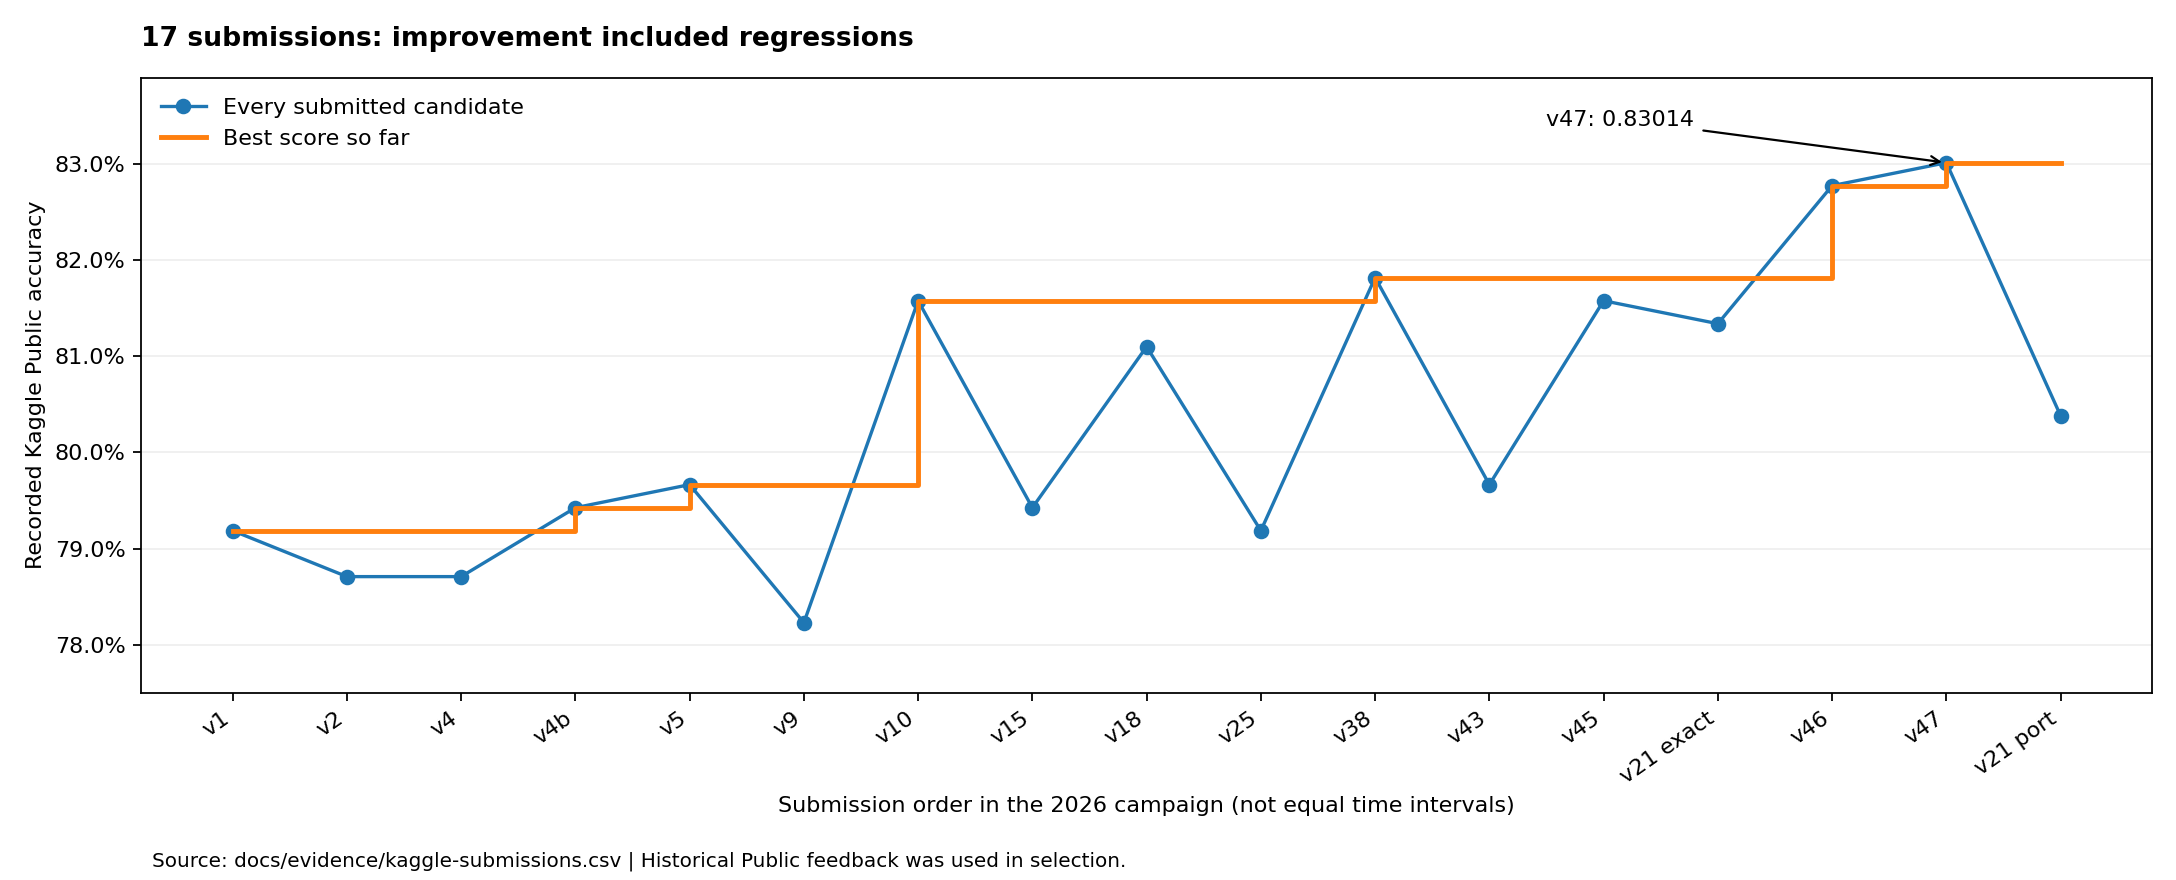

The campaign did not climb smoothly. Several later and more complicated candidates scored below earlier versions. The visible jumps came from a small number of useful changes: the v10 public-method reproduction, the v38 text rescue, and the v46/v47 selective relationship guards.

This is why the notebook preserves all 17 actual submissions instead of showing only the winning path. The failed submissions are evidence about which local improvements did not transfer to the Public leaderboard.


## LLM-assisted research workflow

The ensemble experiments were carried out through a human-guided research workflow. The initial environment and project setup were prepared in Antigravity. After that, GPT web sessions were used for hypothesis planning, code drafting, execution requests, result analysis, error inspection, experiment bookkeeping, and documentation. Computation ran in a connected local Python environment.

The workflow was intentionally human-guided rather than fully autonomous:

1. Read the current plan, discoveries, handoff notes, and prior results.
2. Pick the next hypothesis or audit question.
3. Let GPT draft or modify Python code and invoke the local tools.
4. Compare OOF metrics, fold behavior, changed passenger predictions, and alternative seeds where useful.
5. Preserve failures as well as improvements.
6. Validate the candidate file before external submission.
7. Submit only after user approval, then record the Public score and update the next decision.

Prompts and skills governed the research process; they were not fed to the classifier as predictive features. In this notebook they are supporting methodology, while the primary technical story is the ensemble design and its evolution.


### Human-in-the-loop experiment cycle



The loop above shows the practical division of labor: the user set goals and approved external actions, GPT helped draft and operate experiments, local Python produced the actual models and predictions, and recorded evidence determined the next step. This was iterative research assistance rather than an autonomous always-on agent.


## Skills and workflow rules

Historically confirmed during the original experiment:

- `shepsci/kaggle-skill`: explicitly recorded in the historical project instructions and used for Kaggle validation/operations before submissions.
- project `agents.md` rules: required reading order, versioned experiments, fold-boundary checks for group target statistics, and submission-file checks. This was a project workflow contract rather than a packaged skill.

Used while packaging and publishing this Kaggle companion notebook:

- ChatGPT `kaggle` skill: Kaggle notebook packaging, account/tool checks, dry-run, publication, and run-status workflow.
- ChatGPT `kaggle-competition-ops` skill: submission gates, evidence-boundary checks, and competition-operation safeguards.

The repository did not preserve a complete timestamped inventory of every installed skill and version from the original campaign, so this notebook does not claim one.


## What changed through the campaign

### v1: establish a multi-model baseline

The first baseline extracted Title from Name, built FamilySize and IsAlone, used the first Cabin letter as Deck, imputed Age with Title/Pclass medians, imputed Fare with Pclass/Embarked medians, log-transformed Fare, and counted Ticket frequency. Six tree families were averaged: Random Forest, Extra Trees, Gradient Boosting, XGBoost, LightGBM, and CatBoost. The first Public score was 0.79186.

### v2-v3: feature expansion and group-survival audit

Fare-per-person, family-size groups, married-woman flags, age/class interactions, child flags, and ticket prefixes were explored. Some of these additions reduced Public score. The project then focused heavily on how family/ticket survival statistics were computed, because computing target-derived group statistics before the validation split can let validation labels influence validation features.

### v4b-v5: diversify model errors

The baseline was blended with TabICLv2. Later RuleFit and a three-seed MLP-PLR component were added through hard voting. v5 became a reference point with recorded OOF Accuracy 0.85410 but only Public 0.79665, an early warning that local validation and the Kaggle Public split did not move together reliably.

### v10: reproduce a strong public feature-engineering method

The campaign reproduced the Gunes Evitan Titanic tutorial, including quantile bins, Deck grouping, and family/ticket survival statistics. Its Public score reached 0.81578. The historical implementation computed some target-derived relationship features before CV, so its original OOF is not presented as leakage-free evidence.

### later audits and alternative signals

The project tried typed women/child/adult-male relationship features, empirical-Bayes shrinkage, group-aware validation, pseudo-test style holdouts, nested selection, raw Name/Ticket/Cabin character n-grams, and a numeric ticket-prefix P3 feature. Some candidates improved local validation but failed to improve the Public board.

### v38 -> v46 -> v47: the final submitted lineage

The final high-scoring sequence kept v10 as a strong base and changed only selected predictions. v38 applied a high-confidence text rescue and scored 0.81818. v46 added a narrow Deotte-derived female WCG guard and reached 0.82775. v47 used a broader Deotte female guard and reached 0.83014.

v47 changed 13 predictions relative to v38; the four v46 changes are included inside those 13, so they must not be double-counted.


### A useful negative result: P3 improved several local checks but not the leaderboard

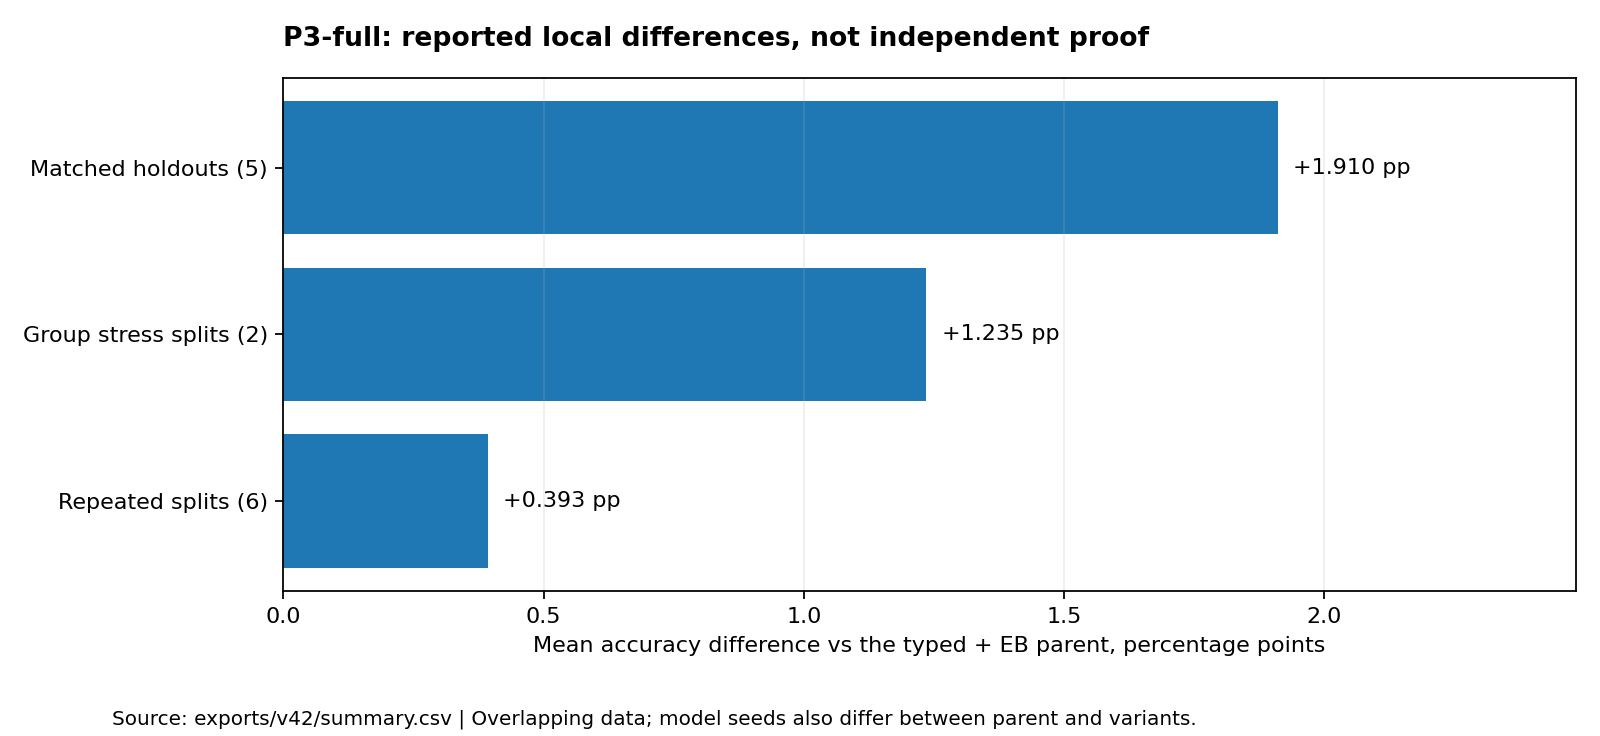

The P3-full ticket-prefix candidate improved its parent on repeated CV, group-aware validation, and pseudo-test checks in the recorded experiments. It was stable across many test predictions and reached a bagged OOF Accuracy of 0.85971. Even so, the submitted P3 candidate scored only 0.79665 Public.

That result mattered because it showed that multiple favorable local diagnostics can still fail to transfer. The project therefore moved away from replacing the whole prediction vector and toward narrowly targeted guards on top of a stronger Public baseline.


In [ ]:
milestones = pd.DataFrame([
    ('v1', 0.79186, 'first multi-model baseline'),
    ('v4b', 0.79425, '90% v1 + 10% TabICLv2'),
    ('v5', 0.79665, 'robust hard vote reference'),
    ('v10', 0.81578, 'Gunes-style historical reproduction'),
    ('v38', 0.81818, 'v10 + high-confidence text rescue'),
    ('v46', 0.82775, 'v38 + narrow female WCG guard'),
    ('v47', 0.83014, 'v38 + broader Deotte female guard'),
], columns=['stage', 'public_score', 'summary'])
display(milestones)


## Final lineage: preserve the strong base, change only selected rows



The strongest late-stage sequence did not retrain one giant final model. It kept the v10-derived base, used v38 as the text-rescued parent, and then applied two differently scoped female relationship guards. v46 changed four additional rows and reached 0.82775; v47 used the broader guard, changed 13 rows relative to v38, and reached 0.83014.

This selective-override pattern is the most important practical ensemble idea in the final stage: preserve predictions with strong accumulated evidence and let a complementary specialist change only the subset where it has a specific rationale.


## Validation and integrity notes

The best Public score is a real recorded Kaggle submission result, but it is not claimed as a sealed, independently validated, leakage-free generalization score.

Important boundaries from the retrospective audit:

- Some historical reproductions computed family/ticket target statistics from the full training labels before cross-validation. That can allow validation labels to affect validation features.
- Some branches combined train and test covariates for transformations. This is transductive use of test inputs; it is different from using hidden test labels, but it is also different from a strict fold-only inductive pipeline.
- The Deotte port contains test prediction lists recovered from public notebook output. Those public predictions are separate from locally generated OOF predictions and should not be presented as if they came from one identical fold-trained model.
- Final v47 includes reused public predictions and candidate selection informed by Public leaderboard feedback.
- Repeated CV, group splits, pseudo-test subsets, and later nested selection all added information, but they did not create a fresh independent test set after every research decision.

So the correct interpretation is: v47 is the selected artifact of this Kaggle campaign and its recorded Public score is 0.83014. It is not promoted to a clean benchmark for general model quality.


### Validation boundary for relationship features



For target-derived family or ticket statistics, excluding only the current row is not enough if another related validation passenger can still contribute a label. The intended strict boundary is to compute validation relationship features from that fold's training labels only. Historical reproductions that did not respect this boundary are kept as historical results, not relabeled as clean OOF evidence.


## Local validation versus Public score

Several experiments illustrate why the project stopped treating local metrics as interchangeable with leaderboard performance:

| Candidate | Recorded local evidence | Public |
|---|---:|---:|
| v5 reference | OOF 0.85410 | 0.79665 |
| v25 majority candidate | local 0.85746 | 0.79186 |
| P3 bagged candidate | OOF 0.85971 | 0.79665 |
| v10 historical reproduction | historical CV not treated as clean | 0.81578 |
| v47 selected artifact | no independent final OOF | 0.83014 |

This gap motivated disagreement analysis, group-aware checks, repeated seeds, and the later integrity audit.


### Local OOF versus actual Public submissions

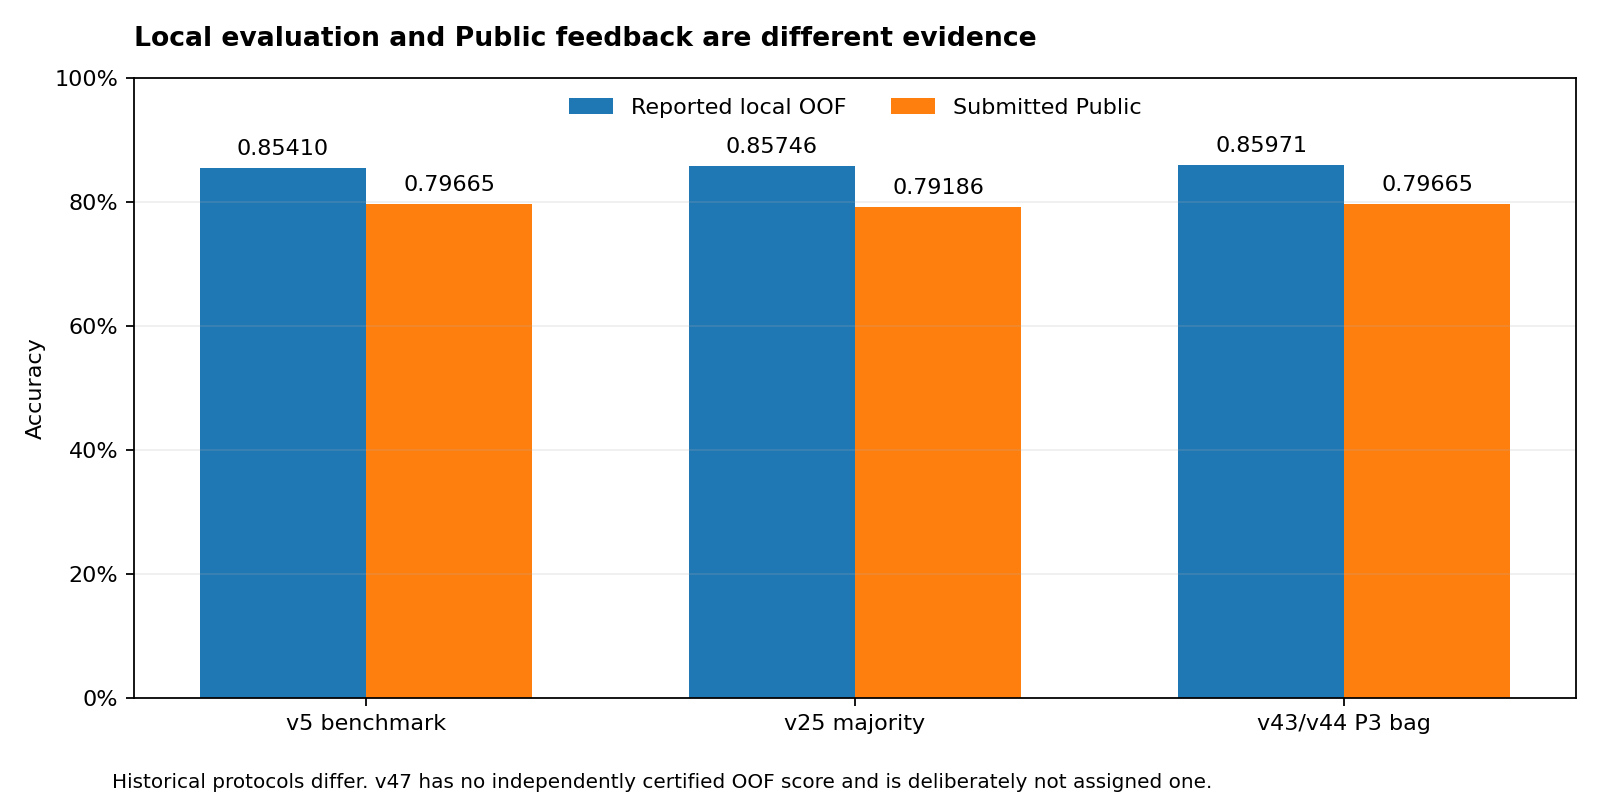

The chart makes the mismatch concrete. v5, v25, and the P3 bagged candidate all looked strong on their recorded local evidence, yet none produced a comparable Public improvement. The lesson is not that OOF is useless; it is that validation assumptions, repeated research decisions, distribution differences, and the exact prediction changes all matter.


## Public notebook comparison points

These were recorded as context, not as independently reproduced benchmarks inside this notebook.

| Public notebook | Displayed score | Current review status |
|---|---:|---|
| Yoni Krichevsky - Top 3% with only 4 features - no data leakage | 0.81818 | primary clean-priority reference; not independently certified |
| Jonathan Oheix - Titanic survivors prediction - TOP 5% | 0.82296 | full code audit pending |
| Chris Deotte - Titanic Deep Net [0.82296] | 0.82296 | full strict-boundary audit pending |
| TensorFlow Decision Forests Titanic notebook | 0.80143 | conservative external baseline |

The project does not place v47's 0.83014 in the same "clean benchmark" bucket because v47 includes public-prediction reuse and leaderboard-adaptive selection.


## Frozen v47 submission replay

The original publication repository can reconstruct v47 from three preserved prediction files and verifies an exact SHA-256. For this Kaggle companion, the already-frozen final CSV is embedded directly in the notebook as an immutable artifact so the notebook remains self-contained and does not depend on GitHub, internet access, model checkpoints, or the Titanic input mount.

This is artifact replay, not model retraining. Running the next cell creates `submission.csv` in `/kaggle/working` (or the current folder outside Kaggle), validates all 418 PassengerIds and binary labels, and verifies the exact recorded SHA-256.


In [ ]:
import base64
import csv
import hashlib
import io
from pathlib import Path

EXPECTED_SHA256 = 'ce8e484730a667e0b5d80068cf8f1418444e0113a9af28996dd8185df60ea0e4'
FROZEN_V47_B64 = '''UGFzc2VuZ2VySWQsU3Vydml2ZWQNCjg5MiwwDQo4OTMsMQ0KODk0LDANCjg5NSwwDQo4OTYsMQ0KODk3LDANCjg5OCwxDQo4OTksMA0KOTAwLDENCjkwMSwwDQo5MDIsMA0KOTAzLDANCjkwNCwxDQo5MDUsMA0KOTA2LDENCjkwNywxDQo5MDgsMA0KOTA5LDANCjkxMCwwDQo5MTEsMQ0KOTEyLDANCjkxMywxDQo5MTQsMQ0KOTE1LDANCjkxNiwxDQo5MTcsMA0KOTE4LDENCjkxOSwwDQo5MjAsMA0KOTIxLDANCjkyMiwwDQo5MjMsMA0KOTI0LDENCjkyNSwwDQo5MjYsMA0KOTI3LDANCjkyOCwwDQo5MjksMA0KOTMwLDANCjkzMSwwDQo5MzIsMA0KOTMzLDANCjkzNCwwDQo5MzUsMQ0KOTM2LDENCjkzNywwDQo5MzgsMA0KOTM5LDANCjk0MCwxDQo5NDEsMQ0KOTQyLDANCjk0MywwDQo5NDQsMQ0KOTQ1LDENCjk0NiwwDQo5NDcsMA0KOTQ4LDANCjk0OSwwDQo5NTAsMA0KOTUxLDENCjk1MiwwDQo5NTMsMA0KOTU0LDANCjk1NSwxDQo5NTYsMQ0KOTU3LDENCjk1OCwxDQo5NTksMA0KOTYwLDANCjk2MSwxDQo5NjIsMQ0KOTYzLDANCjk2NCwxDQo5NjUsMA0KOTY2LDENCjk2NywwDQo5NjgsMA0KOTY5LDENCjk3MCwwDQo5NzEsMQ0KOTcyLDANCjk3MywwDQo5NzQsMA0KOTc1LDANCjk3NiwwDQo5NzcsMA0KOTc4LDENCjk3OSwxDQo5ODAsMA0KOTgxLDENCjk4MiwxDQo5ODMsMA0KOTg0LDENCjk4NSwwDQo5ODYsMA0KOTg3LDANCjk4OCwxDQo5ODksMA0KOTkwLDANCjk5MSwwDQo5OTIsMQ0KOTkzLDANCjk5NCwwDQo5OTUsMA0KOTk2LDENCjk5NywwDQo5OTgsMA0KOTk5LDANCjEwMDAsMA0KMTAwMSwwDQoxMDAyLDANCjEwMDMsMQ0KMTAwNCwxDQoxMDA1LDENCjEwMDYsMQ0KMTAwNywwDQoxMDA4LDANCjEwMDksMQ0KMTAxMCwwDQoxMDExLDENCjEwMTIsMQ0KMTAxMywwDQoxMDE0LDENCjEwMTUsMA0KMTAxNiwwDQoxMDE3LDANCjEwMTgsMA0KMTAxOSwxDQoxMDIwLDANCjEwMjEsMA0KMTAyMiwwDQoxMDIzLDANCjEwMjQsMA0KMTAyNSwwDQoxMDI2LDANCjEwMjcsMA0KMTAyOCwwDQoxMDI5LDANCjEwMzAsMA0KMTAzMSwwDQoxMDMyLDANCjEwMzMsMQ0KMTAzNCwwDQoxMDM1LDANCjEwMzYsMA0KMTAzNywwDQoxMDM4LDANCjEwMzksMA0KMTA0MCwwDQoxMDQxLDANCjEwNDIsMQ0KMTA0MywwDQoxMDQ0LDANCjEwNDUsMA0KMTA0NiwwDQoxMDQ3LDANCjEwNDgsMQ0KMTA0OSwxDQoxMDUwLDANCjEwNTEsMA0KMTA1MiwxDQoxMDUzLDENCjEwNTQsMQ0KMTA1NSwwDQoxMDU2LDANCjEwNTcsMQ0KMTA1OCwwDQoxMDU5LDANCjEwNjAsMQ0KMTA2MSwwDQoxMDYyLDANCjEwNjMsMA0KMTA2NCwwDQoxMDY1LDANCjEwNjYsMA0KMTA2NywxDQoxMDY4LDENCjEwNjksMA0KMTA3MCwxDQoxMDcxLDENCjEwNzIsMA0KMTA3MywxDQoxMDc0LDENCjEwNzUsMA0KMTA3NiwxDQoxMDc3LDANCjEwNzgsMQ0KMTA3OSwwDQoxMDgwLDANCjEwODEsMA0KMTA4MiwwDQoxMDgzLDANCjEwODQsMA0KMTA4NSwwDQoxMDg2LDENCjEwODcsMA0KMTA4OCwxDQoxMDg5LDENCjEwOTAsMA0KMTA5MSwwDQoxMDkyLDENCjEwOTMsMA0KMTA5NCwxDQoxMDk1LDENCjEwOTYsMA0KMTA5NywwDQoxMDk4LDANCjEwOTksMA0KMTEwMCwxDQoxMTAxLDANCjExMDIsMA0KMTEwMywwDQoxMTA0LDANCjExMDUsMQ0KMTEwNiwwDQoxMTA3LDANCjExMDgsMQ0KMTEwOSwwDQoxMTEwLDENCjExMTEsMA0KMTExMiwxDQoxMTEzLDANCjExMTQsMQ0KMTExNSwwDQoxMTE2LDENCjExMTcsMQ0KMTExOCwwDQoxMTE5LDENCjExMjAsMA0KMTEyMSwwDQoxMTIyLDANCjExMjMsMQ0KMTEyNCwwDQoxMTI1LDANCjExMjYsMA0KMTEyNywwDQoxMTI4LDENCjExMjksMA0KMTEzMCwxDQoxMTMxLDENCjExMzIsMQ0KMTEzMywxDQoxMTM0LDENCjExMzUsMA0KMTEzNiwwDQoxMTM3LDANCjExMzgsMQ0KMTEzOSwwDQoxMTQwLDENCjExNDEsMA0KMTE0MiwxDQoxMTQzLDANCjExNDQsMA0KMTE0NSwwDQoxMTQ2LDANCjExNDcsMA0KMTE0OCwwDQoxMTQ5LDANCjExNTAsMQ0KMTE1MSwwDQoxMTUyLDANCjExNTMsMA0KMTE1NCwxDQoxMTU1LDANCjExNTYsMA0KMTE1NywwDQoxMTU4LDANCjExNTksMA0KMTE2MCwwDQoxMTYxLDANCjExNjIsMA0KMTE2MywwDQoxMTY0LDENCjExNjUsMA0KMTE2NiwwDQoxMTY3LDENCjExNjgsMA0KMTE2OSwwDQoxMTcwLDANCjExNzEsMA0KMTE3MiwwDQoxMTczLDENCjExNzQsMQ0KMTE3NSwxDQoxMTc2LDANCjExNzcsMA0KMTE3OCwwDQoxMTc5LDANCjExODAsMA0KMTE4MSwwDQoxMTgyLDANCjExODMsMQ0KMTE4NCwwDQoxMTg1LDENCjExODYsMA0KMTE4NywwDQoxMTg4LDENCjExODksMA0KMTE5MCwwDQoxMTkxLDANCjExOTIsMA0KMTE5MywwDQoxMTk0LDANCjExOTUsMA0KMTE5NiwxDQoxMTk3LDENCjExOTgsMA0KMTE5OSwxDQoxMjAwLDANCjEyMDEsMA0KMTIwMiwwDQoxMjAzLDANCjEyMDQsMA0KMTIwNSwwDQoxMjA2LDENCjEyMDcsMQ0KMTIwOCwwDQoxMjA5LDANCjEyMTAsMA0KMTIxMSwwDQoxMjEyLDANCjEyMTMsMA0KMTIxNCwwDQoxMjE1LDANCjEyMTYsMQ0KMTIxNywwDQoxMjE4LDENCjEyMTksMA0KMTIyMCwwDQoxMjIxLDANCjEyMjIsMQ0KMTIyMywwDQoxMjI0LDANCjEyMjUsMQ0KMTIyNiwwDQoxMjI3LDANCjEyMjgsMA0KMTIyOSwwDQoxMjMwLDANCjEyMzEsMA0KMTIzMiwwDQoxMjMzLDANCjEyMzQsMA0KMTIzNSwxDQoxMjM2LDANCjEyMzcsMQ0KMTIzOCwwDQoxMjM5LDENCjEyNDAsMA0KMTI0MSwxDQoxMjQyLDENCjEyNDMsMA0KMTI0NCwwDQoxMjQ1LDANCjEyNDYsMQ0KMTI0NywwDQoxMjQ4LDENCjEyNDksMA0KMTI1MCwwDQoxMjUxLDANCjEyNTIsMA0KMTI1MywxDQoxMjU0LDENCjEyNTUsMA0KMTI1NiwxDQoxMjU3LDANCjEyNTgsMA0KMTI1OSwwDQoxMjYwLDENCjEyNjEsMA0KMTI2MiwwDQoxMjYzLDENCjEyNjQsMA0KMTI2NSwwDQoxMjY2LDENCjEyNjcsMQ0KMTI2OCwwDQoxMjY5LDANCjEyNzAsMA0KMTI3MSwwDQoxMjcyLDANCjEyNzMsMA0KMTI3NCwwDQoxMjc1LDANCjEyNzYsMA0KMTI3NywxDQoxMjc4LDANCjEyNzksMA0KMTI4MCwwDQoxMjgxLDANCjEyODIsMA0KMTI4MywxDQoxMjg0LDENCjEyODUsMA0KMTI4NiwwDQoxMjg3LDENCjEyODgsMA0KMTI4OSwxDQoxMjkwLDANCjEyOTEsMA0KMTI5MiwxDQoxMjkzLDANCjEyOTQsMQ0KMTI5NSwwDQoxMjk2LDENCjEyOTcsMA0KMTI5OCwwDQoxMjk5LDANCjEzMDAsMQ0KMTMwMSwwDQoxMzAyLDENCjEzMDMsMQ0KMTMwNCwwDQoxMzA1LDANCjEzMDYsMQ0KMTMwNywwDQoxMzA4LDANCjEzMDksMQ0K'''

payload = base64.b64decode(FROZEN_V47_B64)
actual_sha = hashlib.sha256(payload).hexdigest()
assert actual_sha == EXPECTED_SHA256, (actual_sha, EXPECTED_SHA256)

text = payload.decode('utf-8-sig')
rows = list(csv.DictReader(io.StringIO(text)))
assert [int(r['PassengerId']) for r in rows] == list(range(892, 1310))
assert set(int(r['Survived']) for r in rows).issubset({0, 1})
assert len(rows) == 418

output_dir = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')
submission_path = output_dir / 'submission.csv'
submission_path.write_bytes(payload)

print(f'PASS: frozen v47 replayed to {submission_path}')
print(f'rows={len(rows)} | sha256={actual_sha} | recorded Public score=0.83014')
display(pd.read_csv(submission_path).head(10))


In [ ]:
from pathlib import Path

# Optional schema/ID cross-check against an attached Titanic sample submission.
input_root = Path('/kaggle/input')
samples = list(input_root.rglob('gender_submission.csv')) if input_root.exists() else []

if samples:
    sample = pd.read_csv(samples[0])
    candidate = pd.read_csv(submission_path)
    assert list(candidate.columns) == list(sample.columns) == ['PassengerId', 'Survived']
    assert candidate['PassengerId'].tolist() == sample['PassengerId'].tolist()
    print(f'PASS: schema and PassengerId order match {samples[0]}')
else:
    print('Titanic sample submission is not mounted in this run; internal ID/schema checks already passed.')


## How to submit this notebook output

After the notebook run completes:

1. Open the notebook output/files panel and confirm `submission.csv` exists.
2. Use Kaggle's `Submit to Competition` action for Titanic.
3. Select the generated `submission.csv` if Kaggle asks for the output file.
4. The file is the frozen v47 artifact whose recorded Public score in this campaign was 0.83014.

Submitting it again consumes a normal Titanic submission and the score shown by Kaggle is the authoritative score for that submission. This notebook itself only displays the previously recorded 0.83014 until a new submission is made.


## Main lessons

- More features did not automatically improve the leaderboard score.
- Target-derived group features require explicit fold boundaries; leave-one-out on the row alone is not always sufficient when related validation passengers can reveal each other's labels.
- Model diversity mattered more than simply increasing complexity in several stages.
- Strong local OOF did not guarantee a stronger Public score.
- Small targeted prediction changes produced the largest late-stage gains, but Public feedback then became part of the selection process and must be disclosed.
- LLM assistance was most useful as an experiment operator and documentation partner, not as a replacement for validation design or human judgment.
- Preserving failed experiments, hashes, score receipts, and the exact final prediction artifact made the later audit possible.


## Sources and attribution

The campaign referenced several public Titanic approaches, including Gunes Evitan's advanced feature-engineering tutorial and Chris Deotte's WCG/XGBoost and Mega Model work. The final record also compared public notebooks from Yoni Krichevsky, Jonathan Oheix, Chris Deotte, and the TensorFlow Decision Forests Titanic example.

Primary project repository: https://github.com/TaeyanG4/kaggle-titanic-experiments

Relevant public Kaggle sources:

- https://www.kaggle.com/code/gunesevitan/titanic-advanced-feature-engineering-tutorial
- https://www.kaggle.com/code/cdeotte/titanic-wcg-xgboost-0-84688
- https://www.kaggle.com/code/cdeotte/titantic-mega-model-0-84210
- https://www.kaggle.com/code/yoni2k/top-3-with-only-4-features-no-data-leakage
- https://www.kaggle.com/code/jonathanoheix/titanic-survivors-prediction-top-5
- https://www.kaggle.com/code/cdeotte/titanic-deep-net-0-82296
- https://www.kaggle.com/code/gusthema/titanic-competition-w-tensorflow-decision-forests

The GitHub repository remains the archival source for historical scripts, evidence files, manifests, and the full audit trail, but the core story and runnable final submission artifact are reproduced here so the repository is not required to understand or use this notebook.
